# CatBoost-Voight: AI Text Detection

Three-model comparison.

**Models:** A=TF-IDF+LR, B=E5+stylo+POS+readability+CatBoost, C=B+Kogan clusters.

**HPO:** Optuna TPE searches over CatBoost params + loss function + class-weighting strategy.

In [1]:
!pip install -q sentence-transformers catboost optuna textstat
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [ ]:
import json, re, string, pickle, math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import spacy
import textstat
from scipy.sparse import hstack
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, accuracy_score,
    f1_score, fbeta_score, confusion_matrix,
)
from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier, Pool
from tqdm import tqdm

try:
    import torch
    TASK_TYPE = "GPU" if torch.cuda.is_available() else "CPU"
except ImportError:
    TASK_TYPE = "CPU"
print(f"device: {TASK_TYPE}")

optuna.logging.set_verbosity(optuna.logging.WARNING)

NLP = spacy.load("en_core_web_sm", disable=["ner", "parser"])
NLP.add_pipe("sentencizer")

TRN_FILE = "/kaggle/input/datasets/pan25-generative-ai-detection-task1-train/pan25-generative-ai-detection-task1-train/train.jsonl"
VAL_FILE = "/kaggle/input/datasets/pan25-generative-ai-detection-task1-train/pan25-generative-ai-detection-task1-train/val.jsonl"
OUT_DIR = Path("/kaggle/working")
EMB_MODEL = "intfloat/e5-small-v2"
N_CLUSTERS = 20
CHUNK_SENTS = 3
EMB_BATCH = 64
CHUNK_BATCH = 256

# loss_function and auto_class_weights are tuned by optuna
CATBOOST_BASE = {
    "eval_metric": "AUC",
    "random_seed": 42,
    "early_stopping_rounds": 100,
    "task_type": TASK_TYPE,
    "verbose": 100,
}

OPTUNA_N_TRIALS = 40
OPTUNA_FRAC = 0.3

device: GPU


## 1. Data

In [3]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

trn_recs = load_jsonl(TRN_FILE)
val_recs = load_jsonl(VAL_FILE)

KEYS = ["id", "text", "label", "genre", "model"]
def to_df(recs):
    rows = [{k: r.get(k, None) for k in KEYS} for r in recs]
    df = pd.DataFrame(rows)
    df["genre"] = df["genre"].fillna("unknown").astype(str)
    df["model"] = df["model"].fillna("human").astype(str)
    df["label"] = df["label"].astype(int)
    return df

trn_df = to_df(trn_recs)
val_df = to_df(val_recs)
y_trn = trn_df["label"].values
y_val = val_df["label"].values
print(f"train: {len(trn_df)}  val: {len(val_df)}")
print(f"train label balance: ai={y_trn.sum()}  human={(y_trn==0).sum()}  ratio={y_trn.mean():.3f}")

train: 23707  val: 3589
train label balance: ai=14606  human=9101  ratio=0.616


## 2. Features

### 2a. Stylometry

In [4]:
_STOP = set(ENGLISH_STOP_WORDS)


def tokenize_words(txt):
    return re.findall(r"\b\w+\b", txt.lower())

def tokenize_words_raw(txt):
    return re.findall(r"\b\w+\b", txt)

def tokenize_sents(txt):
    sents = re.split(r"(?<=[.!?])\s+", txt.strip())
    return [s for s in sents if s.strip()]

def _mttr(words, win=100):
    if len(words) < win:
        return len(set(words)) / len(words) if words else 0.0
    ttrs = [len(set(words[i:i + win])) / win for i in range(len(words) - win + 1)]
    return float(np.mean(ttrs))

def _hapax_rate(words):
    if not words:
        return 0.0
    counts = Counter(words)
    return sum(1 for c in counts.values() if c == 1) / len(words)

def _dis_legomena_rate(words):
    if not words:
        return 0.0
    counts = Counter(words)
    return sum(1 for c in counts.values() if c == 2) / len(words)

def _yule_k(words):
    if not words:
        return 0.0
    counts = Counter(words)
    N = len(words)
    freq_of_freq = Counter(counts.values())
    M2 = sum(v * f * f for v, f in freq_of_freq.items())
    return 10000 * (M2 - N) / (N * N) if N > 0 else 0.0

def _simpson_d(words):
    if not words:
        return 0.0
    counts = Counter(words)
    N = len(words)
    return sum(c * (c - 1) for c in counts.values()) / (N * (N - 1)) if N > 1 else 0.0

def _burstiness(sents):
    if len(sents) < 2:
        return 0.0
    lengths = [len(tokenize_words(s)) for s in sents]
    mu = np.mean(lengths)
    return float(np.std(lengths) / mu) if mu else 0.0

def _bigram_uniq(words):
    if len(words) < 2:
        return 0.0
    bigrams = list(zip(words, words[1:]))
    return len(set(bigrams)) / len(bigrams)

def _trigram_uniq(words):
    if len(words) < 3:
        return 0.0
    trigrams = list(zip(words, words[1:], words[2:]))
    return len(set(trigrams)) / len(trigrams)

def _repeated_word_ratio(words):
    if not words:
        return 0.0
    counts = Counter(words)
    return sum(1 for c in counts.values() if c > 1) / len(words)


def stylometric_ftrs(txt):
    words = tokenize_words(txt)
    words_raw = tokenize_words_raw(txt)
    sents = tokenize_sents(txt)
    n_words = max(len(words), 1)
    n_sents = max(len(sents), 1)
    n_chars = max(len(txt), 1)
    sent_lens = [len(tokenize_words(s)) for s in sents]
    return {
        "n_chars": n_chars,
        "n_words": n_words,
        "n_sents": n_sents,
        "avg_word_len": float(np.mean([len(w) for w in words])) if words else 0.0,
        "avg_sent_len": n_words / n_sents,
        "sent_len_std": float(np.std(sent_lens)) if sent_lens else 0.0,
        "sent_len_max": float(max(sent_lens)) if sent_lens else 0.0,
        "sent_len_min": float(min(sent_lens)) if sent_lens else 0.0,
        "ttr": len(set(words)) / n_words,
        "mttr": _mttr(words),
        "hapax_rate": _hapax_rate(words),
        "dis_legomena_rate": _dis_legomena_rate(words),
        "yule_k": _yule_k(words),
        "simpson_d": _simpson_d(words),
        "burstiness": _burstiness(sents),
        "bigram_uniq": _bigram_uniq(words),
        "trigram_uniq": _trigram_uniq(words),
        "repeated_word_ratio": _repeated_word_ratio(words),
        "stopword_ratio": sum(1 for w in words if w in _STOP) / n_words,
        "punct_dens": sum(1 for c in txt if c in string.punctuation) / n_chars,
        "comma_ratio": txt.count(",") / n_sents,
        "period_ratio": txt.count(".") / n_sents,
        "question_ratio": txt.count("?") / n_sents,
        "exclaim_ratio": txt.count("!") / n_sents,
        "uppercase_ratio": sum(1 for c in txt if c.isupper()) / n_chars,
        "digit_ratio": sum(1 for c in txt if c.isdigit()) / n_chars,
        "lowercase_ratio": sum(1 for w in words_raw if w.islower()) / max(len(words_raw), 1),
    }


def fingerprint_ftrs(txt):
    words = tokenize_words(txt)
    sents = tokenize_sents(txt)
    n_words = max(len(words), 1)
    n_sents = max(len(sents), 1)
    think_block = int(bool(re.search(r"<think>", txt, re.IGNORECASE)))
    boxed_ans = int(r"\boxed{" in txt)
    em_dash_rate = txt.count("—") / n_sents
    md_density = len(re.findall(r"#{1,6}\s|\*\*|`|\n[-*]\s", txt)) / n_sents
    paras = [p.strip() for p in txt.split("\n\n") if p.strip()]
    if len(paras) >= 2:
        para_lens = [len(tokenize_words(p)) for p in paras]
        mu = float(np.mean(para_lens))
        para_burst = float(np.std(para_lens) / mu) if mu else 0.0
    else:
        para_burst = 0.0
    _SUFFIXES = ("ing", "tion", "ness", "ment", "er", "ly", "ies", "ed", "es", "s")
    def _stem(w):
        for s in _SUFFIXES:
            if w.endswith(s) and len(w) > len(s) + 3:
                return w[:-len(s)]
        return w
    stems = [_stem(w) for w in words]
    stem_voc_rat = len(set(stems)) / len(stems) if stems else 0.0
    return {
        "think_block": float(think_block),
        "boxed_ans": float(boxed_ans),
        "em_dash_rate": em_dash_rate,
        "md_density": md_density,
        "para_burst": para_burst,
        "stem_voc_rat": stem_voc_rat,
    }


def all_stylo_ftrs(txt):
    d = stylometric_ftrs(txt)
    d.update(fingerprint_ftrs(txt))
    return d

In [5]:
_POS_TAGS = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "PROPN",
             "DET", "ADP", "CCONJ", "SCONJ", "NUM"]


def pos_ftrs(txt):
    doc = NLP(txt[:5000])
    tokens = [t for t in doc if not t.is_space]
    n = max(len(tokens), 1)
    counts = Counter(t.pos_ for t in tokens)
    ratios = {f"pos_{p.lower()}": counts.get(p, 0) / n for p in _POS_TAGS}
    total = sum(counts.values())
    probs = [c / total for c in counts.values()] if total else []
    ratios["pos_entropy"] = float(-sum(p * math.log(p + 1e-9) for p in probs))
    bigrams = list(zip([t.pos_ for t in tokens], [t.pos_ for t in tokens][1:]))
    ratios["pos_bigram_div"] = len(set(bigrams)) / max(len(bigrams), 1)
    return ratios


def readability_ftrs(txt):
    return {
        "flesch_ease": textstat.flesch_reading_ease(txt),
        "fk_grade": textstat.flesch_kincaid_grade(txt),
        "gunning_fog": textstat.gunning_fog(txt),
        "smog": textstat.smog_index(txt),
        "ari": textstat.automated_readability_index(txt),
        "coleman_liau": textstat.coleman_liau_index(txt),
    }


def all_ftrs(txt):
    d = all_stylo_ftrs(txt)
    d.update(pos_ftrs(txt))
    d.update(readability_ftrs(txt))
    return d


_READ_NAMES = {"flesch_ease", "fk_grade", "gunning_fog", "smog", "ari", "coleman_liau"}
_KOGAN_NAMES = {"dist_human", "dist_ai", "rel_dist", "nearest_cluster",
                "dist_nearest", "dist_second", "cluster_margin", "chunk_entropy"}

def feature_group(name):
    if re.match(r"e\d{3}$", name):
        return "embedding"
    if name.startswith("pos_"):
        return "pos"
    if name in _READ_NAMES:
        return "readability"
    if name in _KOGAN_NAMES:
        return "kogan"
    return "stylometry"


def group_importance(model):
    groups = {}
    for name, imp in zip(model.feature_names_, model.get_feature_importance()):
        g = feature_group(name)
        groups[g] = groups.get(g, 0.0) + imp
    total = max(sum(groups.values()), 1e-9)
    print("  group importance:")
    for g, s in sorted(groups.items(), key=lambda x: -x[1]):
        print(f"    {g:<14} {s:6.2f}  ({100 * s / total:.1f}%)")


def plot_importance(model, title, n=25, save=True):
    pairs = sorted(zip(model.feature_names_, model.get_feature_importance()),
                   key=lambda x: -x[1])[:n]
    labels_ = [p[0] for p in reversed(pairs)]
    vals = [p[1] for p in reversed(pairs)]
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * n)))
    ax.barh(labels_, vals)
    ax.set_title(title)
    ax.set_xlabel("feature importance")
    fig.tight_layout()
    if save:
        fname = OUT_DIR / f"fi_{title.replace(' ', '_').replace('(', '').replace(')', '')}.png"
        fig.savefig(str(fname), dpi=100)
    plt.show()


def top_features(model, n=20):
    imp = sorted(zip(model.feature_names_, model.get_feature_importance()), key=lambda x: -x[1])
    for name, score in imp[:n]:
        print(f"  {name}: {score:.2f}")

In [6]:
print("computing features (stylo + POS + readability)...")
trn_stylo = pd.DataFrame([all_ftrs(r["text"]) for r in tqdm(trn_recs)])
val_stylo = pd.DataFrame([all_ftrs(r["text"]) for r in tqdm(val_recs)])
print(f"feature matrix shape: {trn_stylo.shape}  columns: {list(trn_stylo.columns)[:8]}...")

computing features (stylo + POS + readability)...


100%|██████████| 3589/3589 [03:19<00:00, 17.99it/s]

feature matrix shape: (23707, 52)  columns: ['n_chars', 'n_words', 'n_sents', 'avg_word_len', 'avg_sent_len', 'sent_len_std', 'sent_len_max', 'sent_len_min']...


### 2b. E5 Embeddings

In [7]:
print(f"loading {EMB_MODEL}...")
emb_model = SentenceTransformer(EMB_MODEL)

def embed(texts, batch_size=EMB_BATCH):
    return emb_model.encode(
        [f"passage: {t}" for t in texts],
        batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True,
    )

trn_emb = embed(trn_df["text"].tolist())
val_emb = embed(val_df["text"].tolist())
print(f"embeddings: train={trn_emb.shape}  val={val_emb.shape}")

loading intfloat/e5-small-v2...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/371 [00:00<?, ?it/s]

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

embeddings: train=(23707, 384)  val=(3589, 384)


### 2c. Kogan Cluster Features

In [8]:
def _doc_ftrs(vec, kmeans, human_c, ai_c):
    v = vec.reshape(1, -1)
    dists = cdist(v, kmeans.cluster_centers_, metric="euclidean")[0]
    nearest = int(np.argmin(dists))
    sorted_d = np.sort(dists)
    return {
        "dist_human": float(cdist(v, human_c)[0, 0]),
        "dist_ai": float(cdist(v, ai_c)[0, 0]),
        "rel_dist": float(cdist(v, human_c)[0, 0] - cdist(v, ai_c)[0, 0]),
        "nearest_cluster": f"c{nearest}",
        "dist_nearest": float(sorted_d[0]),
        "dist_second": float(sorted_d[1]) if len(sorted_d) > 1 else 0.0,
        "cluster_margin": float(sorted_d[1] - sorted_d[0]) if len(sorted_d) > 1 else 0.0,
    }


def _chunk_entropy(texts, emb_model, kmeans, chunk_sents=CHUNK_SENTS, batch_size=CHUNK_BATCH):
    all_chunks, offsets = [], []
    for txt in texts:
        sents = re.split(r"(?<=[.!?])\s+", txt.strip())
        chunks = [" ".join(sents[i:i + chunk_sents])
                  for i in range(0, len(sents), chunk_sents) if sents[i:i + chunk_sents]]
        offsets.append((len(all_chunks), len(all_chunks) + len(chunks)))
        all_chunks.extend(chunks)
    if not all_chunks:
        return [0.0] * len(texts)
    chunk_embs = emb_model.encode(
        [f"passage: {c}" for c in all_chunks],
        batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
    )
    entropies = []
    for start, end in offsets:
        if start == end:
            entropies.append(0.0)
            continue
        labels = kmeans.predict(chunk_embs[start:end])
        counts = np.bincount(labels, minlength=kmeans.n_clusters).astype(float)
        counts /= max(counts.sum(), 1)
        entropies.append(float(-np.sum(counts * np.log(counts + 1e-9))))
    return entropies

In [9]:
print(f"fitting MiniBatchKMeans k={N_CLUSTERS}...")
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=5)
kmeans.fit(trn_emb)

ai_mask = y_trn == 1
human_c = trn_emb[~ai_mask].mean(axis=0, keepdims=True)
ai_c = trn_emb[ai_mask].mean(axis=0, keepdims=True)

print("computing document-level Kogan features...")
trn_kogan = pd.DataFrame([_doc_ftrs(v, kmeans, human_c, ai_c) for v in tqdm(trn_emb)])
val_kogan = pd.DataFrame([_doc_ftrs(v, kmeans, human_c, ai_c) for v in tqdm(val_emb)])
print("computing chunk-level semantic entropy...")
trn_kogan["chunk_entropy"] = _chunk_entropy(trn_df["text"].tolist(), emb_model, kmeans)
val_kogan["chunk_entropy"] = _chunk_entropy(val_df["text"].tolist(), emb_model, kmeans)
print(f"kogan features: {trn_kogan.shape}")

fitting MiniBatchKMeans k=20...
computing document-level Kogan features...


100%|██████████| 3589/3589 [00:00<00:00, 21539.84it/s]


computing chunk-level semantic entropy...
kogan features: (23707, 8)


## 3. Model A — TF-IDF + Logistic Regression

In [10]:
word_vec = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2), min_df=2,
    max_features=100000, sublinear_tf=True,
)
char_vec = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), min_df=2,
    max_features=100000, sublinear_tf=True,
)

X_trn_w = word_vec.fit_transform(trn_df["text"])
X_val_w = word_vec.transform(val_df["text"])
X_trn_c = char_vec.fit_transform(trn_df["text"])
X_val_c = char_vec.transform(val_df["text"])

X_trn_a = hstack([X_trn_w, X_trn_c])
X_val_a = hstack([X_val_w, X_val_c])

clf_a = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                            solver="saga", n_jobs=-1)
clf_a.fit(X_trn_a, y_trn)
proba_a = clf_a.predict_proba(X_val_a)[:, 1]
trn_acc = ((clf_a.predict_proba(X_trn_a)[:, 1] >= 0.5).astype(int) == y_trn).mean()
val_acc = ((proba_a >= 0.5).astype(int) == y_val).mean()
print(f"model_A  train_acc={trn_acc:.3f}  val_acc={val_acc:.3f}")

model_A  train_acc=0.994  val_acc=0.987


## 4. Model B — E5 + Stylometry + POS + Readability + CatBoost

In [11]:
def make_pool(X, y=None, cats=None):
    cats = cats or []
    return Pool(X, y, cat_features=cats, feature_names=list(X.columns))

def build_catboost_params(optuna_params):
    p = {**CATBOOST_BASE}
    p["loss_function"] = optuna_params.get("loss_function", "Logloss")
    p["iterations"] = optuna_params.get("iterations", 1500)
    p["learning_rate"] = optuna_params.get("learning_rate", 0.03)
    p["depth"] = optuna_params.get("depth", 6)
    p["l2_leaf_reg"] = optuna_params.get("l2_leaf_reg", 3.0)
    p["bagging_temperature"] = optuna_params.get("bagging_temperature", 1.0)
    p["random_strength"] = optuna_params.get("random_strength", 1.0)
    p["border_count"] = optuna_params.get("border_count", 128)
    p["min_data_in_leaf"] = optuna_params.get("min_data_in_leaf", 1)
    cw = optuna_params.get("auto_class_weights", "Balanced")
    # auto_class_weights is only supported with Logloss, not CrossEntropy
    if cw != "None" and p.get("loss_function", "Logloss") == "Logloss":
        p["auto_class_weights"] = cw
    return p

def train_catboost(X_trn, X_val, cats=None, optuna_params=None):
    cats = cats or []
    p = build_catboost_params(optuna_params or {})
    model = CatBoostClassifier(**p)
    model.fit(
        make_pool(X_trn, y_trn.astype(float), cats),
        eval_set=make_pool(X_val, y_val.astype(float), cats),
    )
    return model

In [12]:
emb_cols = [f"e{i:03d}" for i in range(trn_emb.shape[1])]

trn_b = pd.concat([
    pd.DataFrame(trn_emb, columns=emb_cols),
    trn_stylo.reset_index(drop=True),
], axis=1)
val_b = pd.concat([
    pd.DataFrame(val_emb, columns=emb_cols),
    val_stylo.reset_index(drop=True),
], axis=1)
trn_b["genre"] = trn_df["genre"].values
val_b["genre"] = val_df["genre"].values
print(f"model_B feature matrix: {trn_b.shape}")

model_B feature matrix: (23707, 437)


### Optuna HPO for CatBoost

In [13]:
from sklearn.metrics import roc_auc_score as _auc

n_sub = max(100, int(len(trn_b) * OPTUNA_FRAC))
sub_idx = np.random.RandomState(42).choice(len(trn_b), n_sub, replace=False)
X_sub = trn_b.iloc[sub_idx].reset_index(drop=True)
y_sub = y_trn[sub_idx].astype(float)
pool_val_b = make_pool(val_b, y_val.astype(float), ["genre"])

def _objective(trial):
    p = {
        "loss_function": trial.suggest_categorical("loss_function",
                                                    ["Logloss", "CrossEntropy"]),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights",
                                                         ["Balanced", "SqrtBalanced", "None"]),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.5),
        "random_strength": trial.suggest_float("random_strength", 0.0, 3.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 20),
    }
    cb_p = {**build_catboost_params(p), "verbose": 0, "early_stopping_rounds": 50}
    model = CatBoostClassifier(**cb_p)
    pool_sub = Pool(X_sub, y_sub, cat_features=["genre"], feature_names=list(X_sub.columns))
    model.fit(pool_sub, eval_set=pool_val_b)
    proba = model.predict_proba(pool_val_b)[:, 1]
    return float(_auc(y_val, proba))

study_b = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=8),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=6),
)
print(f"starting Optuna: {OPTUNA_N_TRIALS} trials  subset={n_sub}/{len(trn_b)}")
study_b.optimize(_objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)

print(f"best trial #{study_b.best_trial.number}  AUC={study_b.best_value:.4f}")
print("best params:")
for k, v in study_b.best_params.items():
    print(f"  {k}: {v:.5g}" if isinstance(v, (int, float)) else f"  {k}: {v}")

starting Optuna: 40 trials  subset=7112/23707


  0%|          | 0/40 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

best trial #39  AUC=0.9966
best params:
  loss_function: Logloss
  auto_class_weights: None
  iterations: 934
  learning_rate: 0.085022
  depth: 7
  l2_leaf_reg: 9.9596
  bagging_temperature: 0.39903
  random_strength: 0.80514
  border_count: 242
  min_data_in_leaf: 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9583645	best: 0.9583645 (0)	total: 221ms	remaining: 3m 26s
100:	test: 0.9959646	best: 0.9959646 (100)	total: 11.5s	remaining: 1m 34s
200:	test: 0.9970404	best: 0.9970410 (199)	total: 22.4s	remaining: 1m 21s
300:	test: 0.9974858	best: 0.9974875 (290)	total: 33.2s	remaining: 1m 9s
400:	test: 0.9976050	best: 0.9976050 (400)	total: 43.8s	remaining: 58.2s
500:	test: 0.9976745	best: 0.9977019 (471)	total: 54s	remaining: 46.7s
bestTest = 0.9977018833
bestIteration = 471
Shrink model to first 472 iterations.
top 20 features:
  para_burst: 11.29
  sent_len_std: 5.64
  genre: 5.28
  stopword_ratio: 4.51
  n_chars: 3.92
  pos_entropy: 3.78
  pos_num: 3.76
  n_words: 3.30
  punct_dens: 3.29
  pos_bigram_div: 3.11
  mttr: 3.00
  comma_ratio: 2.91
  avg_word_len: 2.67
  em_dash_rate: 2.16
  coleman_liau: 2.14
  bigram_uniq: 1.88
  pos_pron: 1.83
  burstiness: 1.59
  pos_cconj: 1.15
  e244: 1.08

  group importance:
    stylometry      57.33  (57.3%)
    embedding       24.69  (24.7%)
    

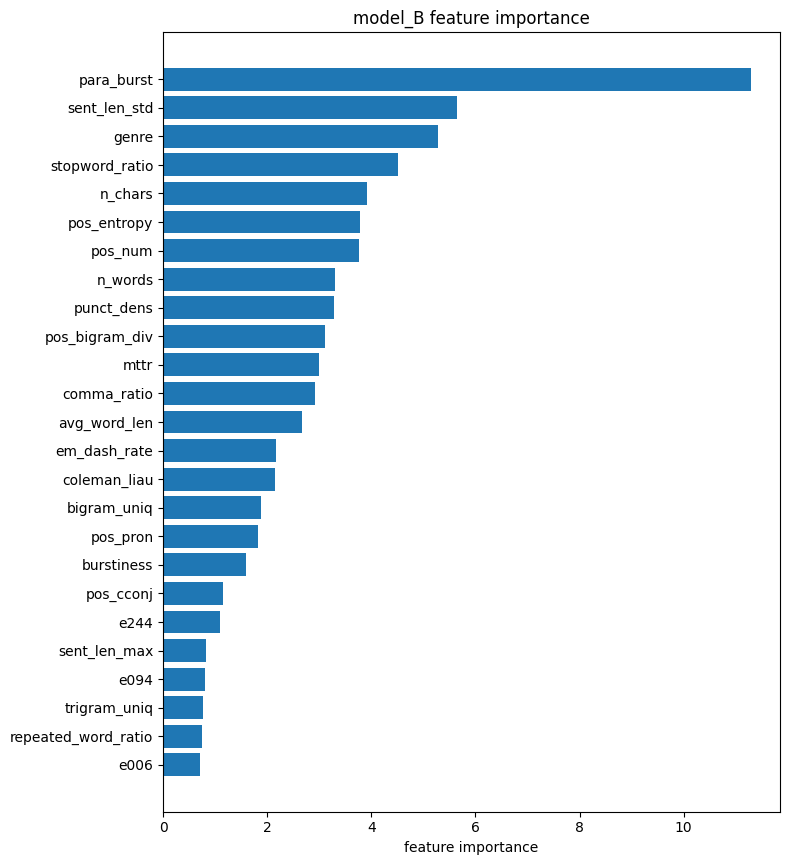

In [14]:
BEST_PARAMS = study_b.best_params
model_b = train_catboost(trn_b, val_b, cats=["genre"], optuna_params=BEST_PARAMS)
model_b.save_model(str(OUT_DIR / "model_b.cbm"))
proba_b = model_b.predict_proba(make_pool(val_b, cats=["genre"]))[:, 1]

print("top 20 features:")
top_features(model_b)
print()
group_importance(model_b)
plot_importance(model_b, "model_B feature importance")

## 5. Model C — E5 + Stylometry + Kogan + CatBoost

model_C feature matrix: (23707, 445)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9681120	best: 0.9681120 (0)	total: 221ms	remaining: 3m 26s
100:	test: 0.9967454	best: 0.9967454 (100)	total: 11.4s	remaining: 1m 34s
200:	test: 0.9974661	best: 0.9974661 (200)	total: 22.4s	remaining: 1m 21s
300:	test: 0.9976484	best: 0.9976586 (291)	total: 33.3s	remaining: 1m 9s
400:	test: 0.9977825	best: 0.9977889 (380)	total: 44s	remaining: 58.4s
500:	test: 0.9978696	best: 0.9978777 (497)	total: 54.5s	remaining: 47.1s
600:	test: 0.9979366	best: 0.9979386 (593)	total: 1m 4s	remaining: 36s
700:	test: 0.9979712	best: 0.9979725 (695)	total: 1m 15s	remaining: 25s
800:	test: 0.9979928	best: 0.9980084 (753)	total: 1m 25s	remaining: 14.2s
900:	test: 0.9980203	best: 0.9980298 (851)	total: 1m 35s	remaining: 3.51s
933:	test: 0.9980206	best: 0.9980298 (851)	total: 1m 39s	remaining: 0us
bestTest = 0.9980297685
bestIteration = 851
Shrink model to first 852 iterations.
top 20 features:
  para_burst: 12.32
  rel_dist: 6.12
  sent_len_std: 5.60
  genre: 4.29
  stopword_ratio: 3.47
  pos_nu

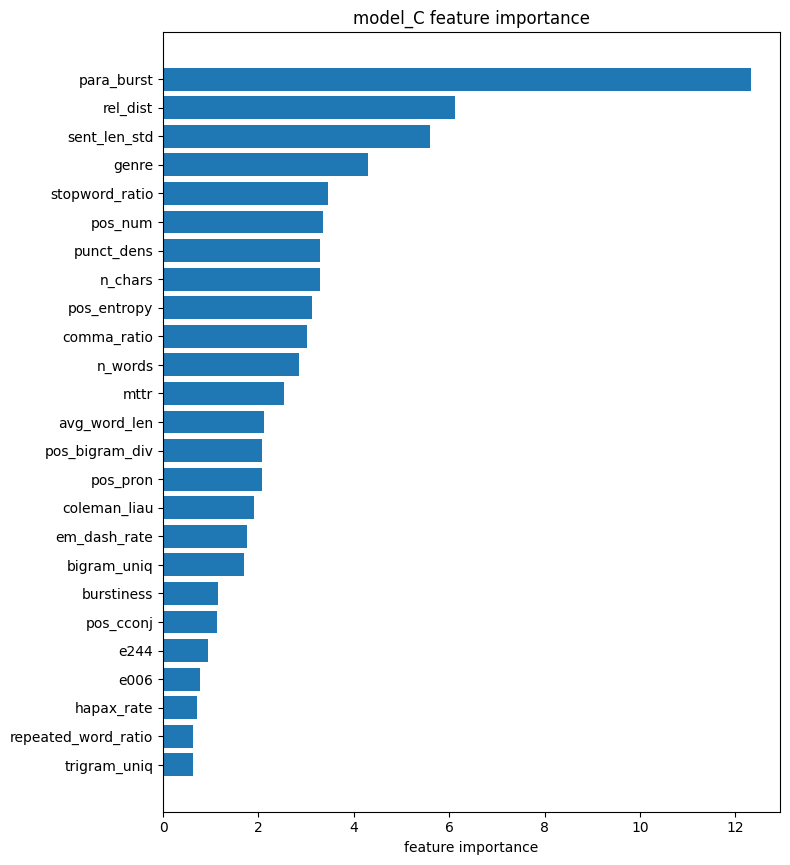

In [15]:
trn_c = pd.concat([trn_b.reset_index(drop=True), trn_kogan.reset_index(drop=True)], axis=1)
val_c = pd.concat([val_b.reset_index(drop=True), val_kogan.reset_index(drop=True)], axis=1)

print(f"model_C feature matrix: {trn_c.shape}")
model_c = train_catboost(trn_c, val_c, cats=["genre", "nearest_cluster"],
                          optuna_params=BEST_PARAMS)
model_c.save_model(str(OUT_DIR / "model_c.cbm"))
proba_c = model_c.predict_proba(make_pool(val_c, cats=["genre", "nearest_cluster"]))[:, 1]

print("top 20 features:")
top_features(model_c)
print()
group_importance(model_c)
plot_importance(model_c, "model_C feature importance")

## 6. Evaluation

In [16]:
def pan_metrics(y_true, proba, thr=0.5):
    y_pred = (proba >= thr).astype(int)
    roc_auc = roc_auc_score(y_true, proba)
    brier = 1.0 - brier_score_loss(y_true, proba)
    c1 = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f05u = fbeta_score(y_true, y_pred, beta=0.5, pos_label=1, zero_division=0)
    mean = float(np.mean([roc_auc, brier, c1, f1, f05u]))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return {
        "ROC-AUC": round(roc_auc, 4), "BRIER": round(brier, 4),
        "C@1": round(c1, 4), "F1": round(f1, 4), "F0.5u": round(f05u, 4),
        "MEAN": round(mean, 4), "FPR": round(fpr, 4), "FNR": round(fnr, 4),
    }

def best_threshold(y_true, proba):
    best_thr, best_mean = 0.5, 0.0
    for thr in np.linspace(0.05, 0.95, 181):
        m = pan_metrics(y_true, proba, thr=thr)
        if m["MEAN"] > best_mean:
            best_mean = m["MEAN"]
            best_thr = float(thr)
    return best_thr

def print_table(rows, title=""):
    if not rows:
        return
    if title:
        print(f"\n{title}")
    cols = list(rows[0].keys())
    widths = {c: max(len(c), max(len(str(r.get(c, ""))) for r in rows)) for c in cols}
    header = "  ".join(c.ljust(widths[c]) for c in cols)
    print(header)
    print("-" * len(header))
    for row in rows:
        print("  ".join(str(row.get(c, "")).ljust(widths[c]) for c in cols))

### Overall results

In [17]:
all_models = {
    "model_A (tfidf+lr)": proba_a,
    "model_B (e5+stylo+pos+read)": proba_b,
    "model_C (e5+stylo+pos+kogan)": proba_c,
}

overall_rows = []
for name, proba in all_models.items():
    thr = best_threshold(y_val, proba)
    m = pan_metrics(y_val, proba, thr=thr)
    overall_rows.append({"system": name, "thr": round(thr, 2), **m})

print_table(overall_rows, title="OVERALL")
pd.DataFrame(overall_rows).to_csv(OUT_DIR / "eval_results.csv", index=False)


OVERALL
system                        thr   ROC-AUC  BRIER   C@1     F1      F0.5u   MEAN    FPR     FNR   
---------------------------------------------------------------------------------------------------
model_A (tfidf+lr)            0.53  0.998    0.9857  0.988   0.9907  0.9931  0.9911  0.0094  0.0134
model_B (e5+stylo+pos+read)   0.69  0.9977   0.9857  0.9822  0.9861  0.9882  0.988   0.0188  0.0173
model_C (e5+stylo+pos+kogan)  0.59  0.998    0.9872  0.9844  0.9879  0.9879  0.9891  0.0219  0.0121


### Per genre

In [18]:
for name, proba in all_models.items():
    rows = []
    for genre in sorted(val_df["genre"].unique()):
        mask = val_df["genre"].values == genre
        if mask.sum() < 10:
            continue
        thr = best_threshold(y_val[mask], proba[mask])
        m = pan_metrics(y_val[mask], proba[mask], thr=thr)
        rows.append({"genre": genre, "n": int(mask.sum()), "thr": round(thr, 2), **m})
    print_table(rows, title=name)


model_A (tfidf+lr)
genre    n     thr   ROC-AUC  BRIER   C@1     F1      F0.5u   MEAN    FPR     FNR   
------------------------------------------------------------------------------------
essays   665   0.52  0.9994   0.9873  0.991   0.9944  0.9966  0.9937  0.0076  0.0094
fiction  1837  0.24  0.9976   0.9886  0.9918  0.9917  0.9947  0.9929  0.0032  0.0132
news     1087  0.58  0.9975   0.9797  0.9899  0.9937  0.9913  0.9904  0.0415  0.0023

model_B (e5+stylo+pos+read)
genre    n     thr   ROC-AUC  BRIER   C@1     F1      F0.5u   MEAN    FPR     FNR   
------------------------------------------------------------------------------------
essays   665   0.76  0.9988   0.9889  0.9895  0.9934  0.994   0.9929  0.0227  0.0075
fiction  1837  0.39  0.9987   0.9926  0.9935  0.9934  0.994   0.9944  0.0054  0.0077
news     1087  0.67  0.9894   0.9722  0.9669  0.9793  0.9787  0.9773  0.0876  0.0195

model_C (e5+stylo+pos+kogan)
genre    n     thr   ROC-AUC  BRIER   C@1     F1      F0.5u   MEAN    F

### Plain AI vs obfuscated AI

In [19]:
para_mask = val_df["model"].str.contains("paraphrase", na=False).values

for name, proba in all_models.items():
    rows = []
    for label, mask in [
        ("all", np.ones(len(y_val), dtype=bool)),
        ("plain", ~para_mask | (y_val == 0)),
        ("obfuscated", para_mask | (y_val == 0)),
    ]:
        sub_y = y_val[mask]
        if sub_y.sum() == 0 or (sub_y == 0).sum() == 0:
            continue
        thr = best_threshold(sub_y, proba[mask])
        m = pan_metrics(sub_y, proba[mask], thr=thr)
        rows.append({"condition": label, "n": int(mask.sum()), "thr": round(thr, 2), **m})
    print_table(rows, title=name)


model_A (tfidf+lr)
condition   n     thr   ROC-AUC  BRIER   C@1     F1      F0.5u   MEAN    FPR     FNR   
---------------------------------------------------------------------------------------
all         3589  0.53  0.998    0.9857  0.988   0.9907  0.9931  0.9911  0.0094  0.0134
plain       3460  0.53  0.998    0.986   0.9879  0.9903  0.9928  0.991   0.0094  0.0137
obfuscated  1406  0.6   0.9985   0.9836  0.9922  0.9585  0.9435  0.9753  0.007   0.0155

model_B (e5+stylo+pos+read)
condition   n     thr   ROC-AUC  BRIER   C@1     F1      F0.5u   MEAN    FPR     FNR   
---------------------------------------------------------------------------------------
all         3589  0.69  0.9977   0.9857  0.9822  0.9861  0.9882  0.988   0.0188  0.0173
plain       3460  0.69  0.9978   0.986   0.9832  0.9867  0.988   0.9884  0.0188  0.0156
obfuscated  1406  0.92  0.9954   0.9744  0.9794  0.8826  0.9068  0.9477  0.007   0.155 

model_C (e5+stylo+pos+kogan)
condition   n     thr   ROC-AUC  BRIER   

### Feature importance: Optuna loss function comparison

In [20]:
completed = [t for t in study_b.trials if t.value is not None]
print(f"completed trials: {len(completed)}")

import collections
for param in ("loss_function", "auto_class_weights"):
    vals = [t.params[param] for t in completed if param in t.params]
    if not vals:
        continue
    cnt = collections.Counter(vals)
    mean_by_val = {}
    for v in cnt:
        sub = [t.value for t in completed if t.params.get(param) == v and t.value is not None]
        mean_by_val[v] = float(np.mean(sub)) if sub else 0.0
    print(f"\n{param}:")
    for v in sorted(mean_by_val, key=lambda x: -mean_by_val[x]):
        print(f"  {v:<20} trials={cnt[v]:3d}  mean_auc={mean_by_val[v]:.4f}")

completed trials: 40

loss_function:
  CrossEntropy         trials= 21  mean_auc=0.9956
  Logloss              trials= 19  mean_auc=0.9955

auto_class_weights:
  Balanced             trials= 23  mean_auc=0.9958
  SqrtBalanced         trials= 10  mean_auc=0.9953
  None                 trials=  7  mean_auc=0.9951
